<h1> <center>GIS - Mini Project 2 </center>

In [46]:
#Import Required Library
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely import Point
from matplotlib import pyplot as plt
import matplotlib_map_utils as mapu
import matplotlib_map_utils as mu

In [47]:
#Change my working directory
os.getcwd()
path =r'C:/Users/aksha/Downloads/InclassAssignment2'
os.chdir(path)

In [48]:
# Load the transmissivity values and Jefferson County boundaries
Tvalues = gpd.read_file("pwells2.gpkg")

# Load the Jefferson County map (WGS84)
fJeff = 'Jefferson.gpkg'
Jeff = gpd.read_file(fJeff)

# Reproject the map to EPSG:6350 (Albers Equal Area)
Jeff = Jeff.to_crs("EPSG:6350")

# Save the reprojected map to a new GeoPackage
Jeff.to_file('Jefferson_6350.gpkg', driver='GPKG')

# Check the columns in Tvalues
print(Tvalues.columns)

Index(['field_1', 'StateWellNumber', 'County', 'LongitudeDD', 'LatitudeDD',
       'LandSurfaceElevation', 'WellDepth', 'WaterElevation', 'DepthFromLSD',
       'Interpolated', 'TSQFTD', 'top_1', 'bot_1', 'bot_2', 'bot_3', 'bot_4',
       'bot_5', 'bot_6', 'geometry'],
      dtype='object')


In [49]:
# Load the transmissivity values GeoDataFrame
Tvalues = gpd.read_file("pwells2.gpkg")  # Adjust the path as needed

# Get the specific column headers
specific_columns = ['field_1', 'LongitudeDD', 'LatitudeDD', 'TSQFTD']
column_headers = Tvalues[specific_columns].columns.tolist()

# Print the specific column headers
print("Column Headers:", column_headers)

# Print all column data for the selected columns
print(Tvalues[specific_columns])

Column Headers: ['field_1', 'LongitudeDD', 'LatitudeDD', 'TSQFTD']
   field_1  LongitudeDD  LatitudeDD  TSQFTD
0        0   -94.266112   30.134722    3358
1        3   -94.271389   30.159167    3351
2       16   -94.407223   30.073611    3190
3       25   -94.275555   30.089167    3333
4       26   -94.291667   30.096389    3316
5      101   -93.908612   29.968055    3247
6      190   -94.199722   29.742500    2849
7      191   -94.164167   29.741389    2905
8      194   -94.072778   29.667778    3032


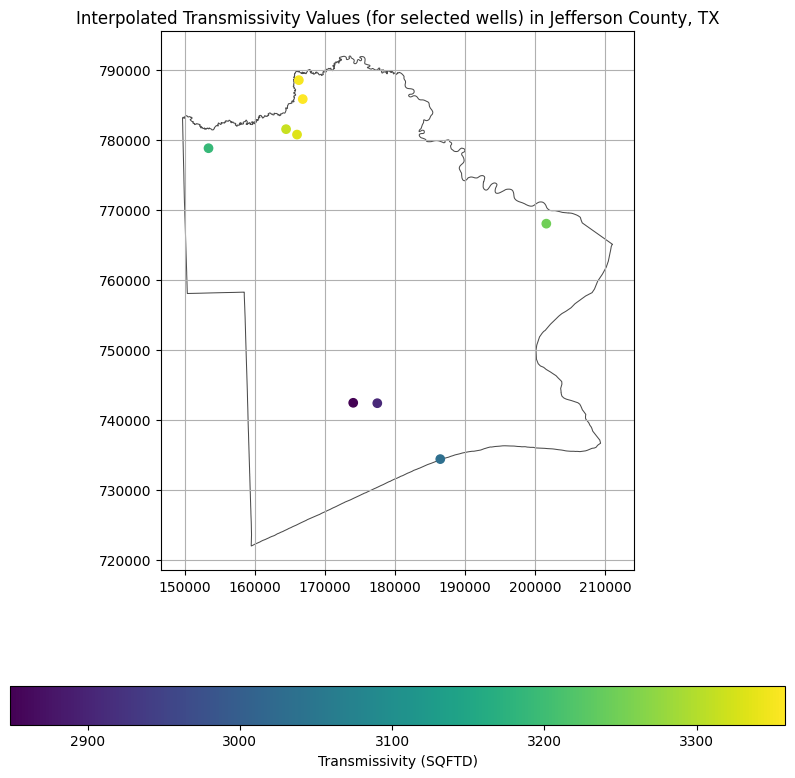

In [50]:
# Ensure both GeoDataFrames are in EPSG:6350
Tvalues = Tvalues.to_crs(epsg=6350)
Jeff = Jeff.to_crs(epsg=6350)

# Plotting the map
fig, ax = plt.subplots(figsize=(10, 10))

# Plot Jefferson County boundary
Jeff.plot(ax=ax, color='none', edgecolor='black', alpha=0.7, linewidth=0.75)

# Plot transmissivity values as a color-coded layer
# Assuming 'Transmissivity' is the column name in Tvalues containing the interpolated transmissivity values
Tvalues.plot(column='TSQFTD', ax=ax, cmap='viridis', legend=True,
             legend_kwds={'label': "Transmissivity (SQFTD)", 'orientation': "horizontal"})

# Add title and grid
plt.title("Interpolated Transmissivity Values (for selected wells) in Jefferson County, TX")
plt.grid(visible=True)

# Display the map
plt.show()

In [51]:
# Print the CRS of both GeoDataFrames
print("CRS of Tvalues:", Tvalues.crs)
print("CRS of Jeff:", Jeff.crs)

CRS of Tvalues: EPSG:6350
CRS of Jeff: EPSG:6350


In [52]:
selected_id = [6154901,6161602,6162303,6162305,6424502,6301301,6154905,6423302,6423201]
selected_wells = Tvalues.loc[Tvalues['StateWellNumber'] == selected_id]
selected_wells

,field_1,StateWellNumber,County,LongitudeDD,LatitudeDD,LandSurfaceElevation,WellDepth,WaterElevation,DepthFromLSD,Interpolated,TSQFTD,top_1,bot_1,bot_2,bot_3,bot_4,bot_5,bot_6,geometry
0,0,6154901,Jefferson,-94.266112,30.134722,30.0,21.0,23.10,6.90,25117.877,3358,7.84802,-7.15198,-423.0,-789.0,-986.0,-1533.111,-2221.0,POINT (166834.847 785849.276)
5,101,6301301,Jefferson,-93.908612,29.968055,12.0,1000.0,-3.32,15.32,24292.489,3247,2.47877,-12.52123,-483.0,-1290.0,-1482.0,-2222.534,-2918.0,POINT (201635.486 768048.647)
7,191,6423302,Jefferson,-94.164167,29.741389,3.0,70.0,1.90,1.10,21731.358,2905,1.53150,-13.46850,-576.0,-1401.0,-1614.0,-2465.575,-3288.0,POINT (177485.844 742399.036)


In [55]:
# Calculate Hydraulic Head assuming 'WaterElevation' and 'DepthFromLSD' (
Tvalues['Hydraulic_Head'] = Tvalues['WaterElevation'] + Tvalues['DepthFromLSD']
Tvalues

,field_1,StateWellNumber,County,LongitudeDD,LatitudeDD,LandSurfaceElevation,WellDepth,WaterElevation,DepthFromLSD,Interpolated,TSQFTD,top_1,bot_1,bot_2,bot_3,bot_4,bot_5,bot_6,geometry,Hydraulic_Head
0,0,6154901,Jefferson,-94.266112,30.134722,30.0,21.0,23.100000,6.900000,25117.877,3358,7.84802,-7.15198,-423.0,-789.0,-986.0,-1533.111,-2221.0,POINT (166834.847 785849.276),30.0
1,3,6154905,Jefferson,-94.271389,30.159167,26.0,572.0,-25.338571,51.338571,25067.736,3351,7.76283,-7.23717,-408.0,-750.0,-943.0,-1469.906,-2155.0,POINT (166277.794 788553.163),26.0
2,16,6161602,Jefferson,-94.407223,30.073611,36.0,300.0,29.300000,6.700000,23861.639,3190,11.34370,-3.65630,-422.0,-844.0,-1033.0,-1528.316,-2262.0,POINT (153372.144 778829.428),36.0
3,25,6162303,Jefferson,-94.275555,30.089167,38.0,102.0,30.000000,8.000000,24935.938,3333,11.82590,-3.17410,-438.0,-848.0,-1054.0,-1640.914,-2336.0,POINT (166018.091 780777.008),38.0
4,26,6162305,Jefferson,-94.291667,30.096389,39.0,208.0,31.000000,8.000000,24804.142,3316,11.60230,-3.39770,-431.0,-818.0,-1030.0,-1596.809,-2295.0,POINT (164452.693 781550.465),39.0
5,101,6301301,Jefferson,-93.908612,29.968055,12.0,1000.0,-3.320000,15.320000,24292.489,3247,2.47877,-12.52123,-483.0,-1290.0,-1482.0,-2222.534,-2918.0,POINT (201635.486 768048.647),12.0
6,190,6423201,Jefferson,-94.199722,29.742500,5.0,178.0,1.800000,3.200000,21313.933,2849,1.58218,-13.41782,-572.0,-1373.0,-1586.0,-2462.670,-3265.0,POINT (174046.516 742456.471),5.0
7,191,6423302,Jefferson,-94.164167,29.741389,3.0,70.0,1.900000,1.100000,21731.358,2905,1.53150,-13.46850,-576.0,-1401.0,-1614.0,-2465.575,-3288.0,POINT (177485.844 742399.036),3.0
8,194,6424502,Jefferson,-94.072778,29.667778,5.0,10.0,2.000000,3.000000,22679.151,3032,1.78449,-13.21551,-630.0,-1534.0,-1772.0,-2645.063,-3526.0,POINT (186485.561 734412.408),5.0


In [56]:
# Load mean water levels file and convert to AEA projection
mean_water_levels_gdf = gpd.read_file("pwells2.gpkg")
mean_water_levels_gdf = mean_water_levels_gdf.to_crs("EPSG:6350")  # AEA projection

# Compute X and Y coordinates in AEA
mean_water_levels_gdf['X'] = mean_water_levels_gdf.geometry.x
mean_water_levels_gdf['Y'] = mean_water_levels_gdf.geometry.y
print(mean_water_levels_gdf[['X', 'Y']].head())

               X              Y
0  166834.846987  785849.276114
1  166277.793526  788553.162588
2  153372.144389  778829.427503
3  166018.090732  780777.008066
4  164452.693490  781550.465279


In [57]:
# Ensuring 'Hydraulic_Head' is available in the mean_water_levels_gdf DataFrame by merging with Tvalues
mean_water_levels_gdf = mean_water_levels_gdf.merge(Tvalues[['StateWellNumber', 'Hydraulic_Head']], on='StateWellNumber', how='left')

# Regression
X = mean_water_levels_gdf[['X', 'Y']]
X = sm.add_constant(X)  # Add intercept
y = mean_water_levels_gdf['Hydraulic_Head']

# Fit linear regression model
model = sm.OLS(y, X).fit()
gradient_x, gradient_y = model.params['X'], model.params['Y']

# Output gradients
print(f"Gradient with respect to X: {gradient_x}")
print(f"Gradient with respect to Y: {gradient_y}")

Gradient with respect to X: -0.00036531043634435847
Gradient with respect to Y: 0.0005061968739646671


In [58]:
# Resultant gradient
resultant_gradient = np.sqrt(gradient_x**2 + gradient_y**2)
print("Resultant Hydraulic Gradient:", resultant_gradient)

Resultant Hydraulic Gradient: 0.0006242491410596467


In [59]:
#Converting Lat, Lon to EPSG:6350, & calculating hydraulic head accordingly

#Loading file
file_gc_mean_water_level = 'JGCMeanWL.csv'
df = pd.read_csv(file_gc_mean_water_level)

# Create geometry from 'LongitudeDD' and 'LatitudeDD' columns
geometry = [Point(xy) for xy in zip(df['LongitudeDD'], df['LatitudeDD'])]

# Create a GeoDataFrame with the initial geometry
gdf = gpd.GeoDataFrame(df, geometry=geometry)

# Set the initial CRS to WGS84 (EPSG:4326)
gdf.set_crs(epsg=4326, inplace=True)

# Convert the CRS to Albers Equal Area Conic CONUS, NAD 83 (2011); EPSG:6350
gdf = gdf.to_crs(epsg=6350)

# Extract the transformed coordinates (X, Y) and add them as new columns
gdf['LON6350'] = gdf.geometry.x
gdf['LAT6350'] = gdf.geometry.y

# Calculate 'Hydraulic_Head_MSL' using 'WaterElevation' and 'DepthFromLSD' columns
gdf['Hydraulic_Head'] = gdf['WaterElevation'] + gdf['DepthFromLSD']

gdf.head()

,Unnamed: 0,StateWellNumber,County,LongitudeDD,LatitudeDD,LandSurfaceElevation,WellDepth,WaterElevation,DepthFromLSD,geometry,LON6350,LAT6350,Hydraulic_Head
0,0,6154901,Jefferson,-94.266112,30.134722,30.0,21.0,23.100000,6.900000,POINT (166834.847 785849.276),166834.846987,785849.276114,30.0
1,1,6154902,Jefferson,-94.271111,30.159167,28.0,450.0,-17.178889,45.178889,POINT (166304.523 788553.616),166304.522818,788553.615566,28.0
2,2,6154904,Jefferson,-94.270278,30.161667,27.0,530.0,-17.287143,44.287143,POINT (166379.619 788832.556),166379.619326,788832.555902,27.0
3,3,6154905,Jefferson,-94.271389,30.159167,26.0,572.0,-25.338571,51.338571,POINT (166277.794 788553.163),166277.793526,788553.162588,26.0
4,7,6155701,Jefferson,-94.213889,30.130555,36.0,68.0,27.000000,9.000000,POINT (171867.858 785479.863),171867.858370,785479.863195,36.0


In [62]:
from shapely.geometry import Polygon

# Define the capture zone polygon (adjust as needed)
polygon_points = [(0, 0), (0, -resultant_gradient), (resultant_gradient, 0)]
capture_zone_polygon = Polygon(polygon_points)
print(f"Capture Zone Polygon Coordinates: {polygon_points}")

Capture Zone Polygon Coordinates: [(0, 0), (0, -0.0006242491410596467), (0.0006242491410596467, 0)]


In [63]:
capture_zone_gdf = gpd.GeoDataFrame(geometry=[capture_zone_polygon], crs="EPSG:6350")
print(capture_zone_gdf)

                                  geometry
0  POLYGON ((0 0, 0 -0.001, 0.001 0, 0 0))


In [ ]:
angle = np.degrees(np.arctan2(gradient_y, gradient_x))
print(f"Calculated Rotation Angle (degrees): {angle}")

# Rotate the capture zone polygon around its centroid by the calculated angle
rotated_capture_zone_polygon = rotate(capture_zone_polygon, angle, origin='centroid')
print("Rotated Capture Zone Polygon Coordinates:")
print(rotated_capture_zone_polygon)

# Convert rotated polygon into a GeoDataFrame for further operations
rotated_capture_zone_gdf = gpd.GeoDataFrame(geometry=[rotated_capture_zone_polygon], crs="EPSG:6350")


In [ ]:
from mpl_toolkits.mplot3d import Axes3D
# Coordinates for 9 wells
well_ids = [6164505, 6161602, 6162303, 6162305, 6424502, 6301301, 6154905, 6423302, 6423201]
latitude = [30.053056, 30.066944, 30.071256, 30.086445, 30.056632, 30.089123, 30.095601, 30.102345, 30.112678]
longitude = [-94.03889, -94.03889, -94.03906, -94.04322, -94.04567, -94.05355, -94.06556, -94.07567, -94.08033]
hydraulic_head = [26.0, 24.999999, 25.5, 24.8, 26.2, 25.0, 24.6, 25.4, 24.7]

# Create a figure for 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Plot the wells in 3D space
ax.scatter(longitude, latitude, hydraulic_head, c='r', marker='o')

# Labels for the axes
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Hydraulic Head (m)')

# Title
plt.title('Hydraulic Head at Selected Wells')

# Show the plot
plt.show()

In [ ]:
from shapely import affinity
from shapely.geometry import Polygon
# Translate the capture zone polygon to match the approximate Jefferson County area
capture_zone_polygon_translated = affinity.translate(rotated_capture_zone_polygon, xoff=200000, yoff=700000)

# Convert the translated polygon to a GeoDataFrame
translated_capture_zone_gdf = gpd.GeoDataFrame(geometry=[capture_zone_polygon_translated], crs="EPSG:6350")

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the Jefferson County map
Jefferson.plot(ax=ax, color='lightgrey', edgecolor='black', linewidth=0.75)
print("Plotted Jefferson County Map.")

# Overlay the translated capture zone
translated_capture_zone_gdf.plot(ax=ax, color='blue', alpha=0.5, edgecolor='darkblue')
print("Overlayed the translated capture zone on the map.")

# Adjust the plot view limits to focus on the area where the polygon is located
ax.set_xlim(100000, 300000)
ax.set_ylim(600000, 800000)

# Additional plot embellishments
plt.title("Translated Capture Zone Overlay on Jefferson County Map")
plt.xlabel("X Coordinate (m)")
plt.ylabel("Y Coordinate (m)")
plt.grid(True)
plt.show()


In [ ]:
output_file = "rotated_capture_zone.gpkg"
rotated_capture_zone_gdf.to_file(output_file, driver="GPKG")
print(f"Rotated capture zone polygon exported to '{output_file}'")